In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("clean_data.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (835971, 9)


,environment,test,sensor,sample_index,timestamp,addr,rssi,lqi,source_file
0,bridge,1,sensor_1,1,"2026-03-05 16:36:37,951",fe80::e41d:23d2:4964:c6f9,-88,20,Bridge 1.log
1,bridge,1,sensor_1,2,"2026-03-05 16:36:37,956",fe80::e41d:23d2:4964:c6f9,-87,24,Bridge 1.log
2,bridge,1,sensor_1,3,"2026-03-05 16:36:37,976",fe80::e41d:23d2:4964:c6f9,-88,20,Bridge 1.log
3,bridge,1,sensor_1,4,"2026-03-05 16:36:37,990",fe80::e41d:23d2:4964:c6f9,-88,20,Bridge 1.log
4,bridge,1,sensor_1,5,"2026-03-05 16:36:37,999",fe80::e41d:23d2:4964:c6f9,-88,20,Bridge 1.log


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835971 entries, 0 to 835970
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   environment   835971 non-null  object
 1   test          835971 non-null  int64 
 2   sensor        835971 non-null  object
 3   sample_index  835971 non-null  int64 
 4   timestamp     835971 non-null  object
 5   addr          835971 non-null  object
 6   rssi          835971 non-null  int64 
 7   lqi           835971 non-null  int64 
 8   source_file   835971 non-null  object
dtypes: int64(4), object(5)
memory usage: 57.4+ MB


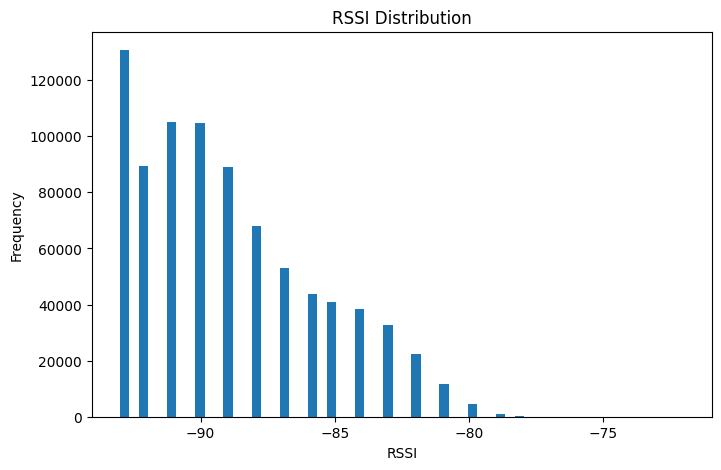

In [6]:
plt.figure(figsize=(8,5))

plt.hist(df["rssi"], bins=60)

plt.title("RSSI Distribution")
plt.xlabel("RSSI")
plt.ylabel("Frequency")

plt.show()

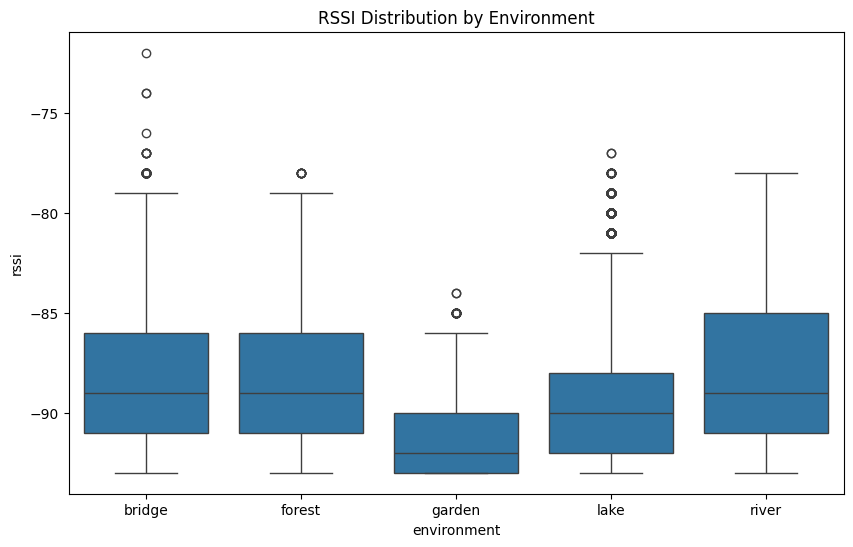

In [8]:
plt.figure(figsize=(10,6))

sns.boxplot(x="environment", y="rssi", data=df)

plt.title("RSSI Distribution by Environment")

plt.show()

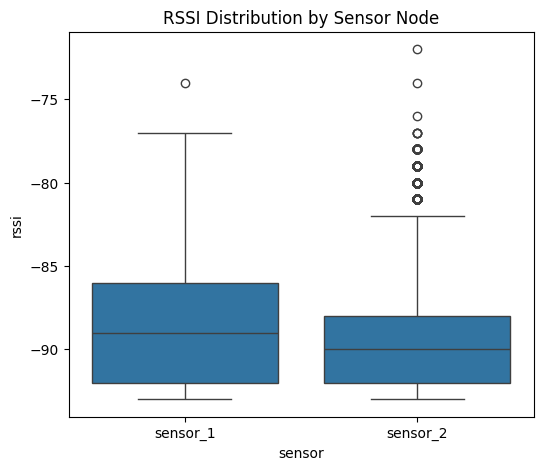

In [10]:
plt.figure(figsize=(6,5))

sns.boxplot(x="sensor", y="rssi", data=df)

plt.title("RSSI Distribution by Sensor Node")

plt.show()

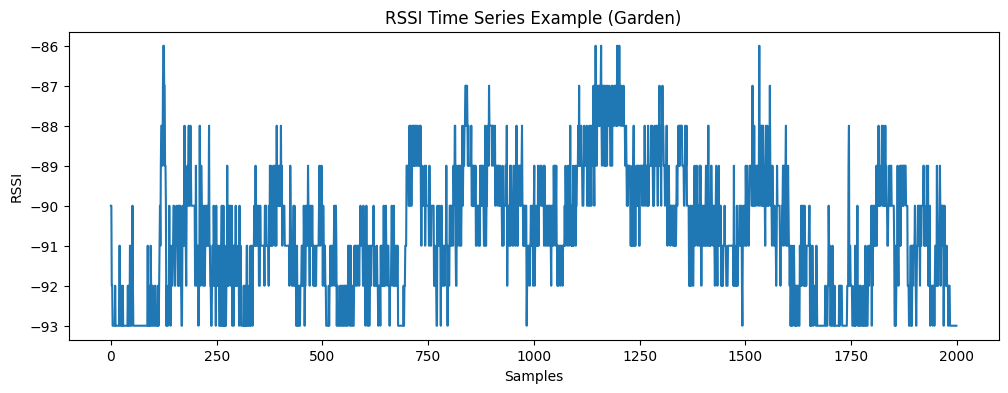

In [12]:
sample = df[df["environment"]=="garden"]

plt.figure(figsize=(12,4))

plt.plot(sample["rssi"].values[:2000])

plt.title("RSSI Time Series Example (Garden)")
plt.xlabel("Samples")
plt.ylabel("RSSI")

plt.show()

In [13]:
df["run_id"] = (
    df["environment"] + "_" +
    df["test"].astype(str) + "_" +
    df["sensor"]
)

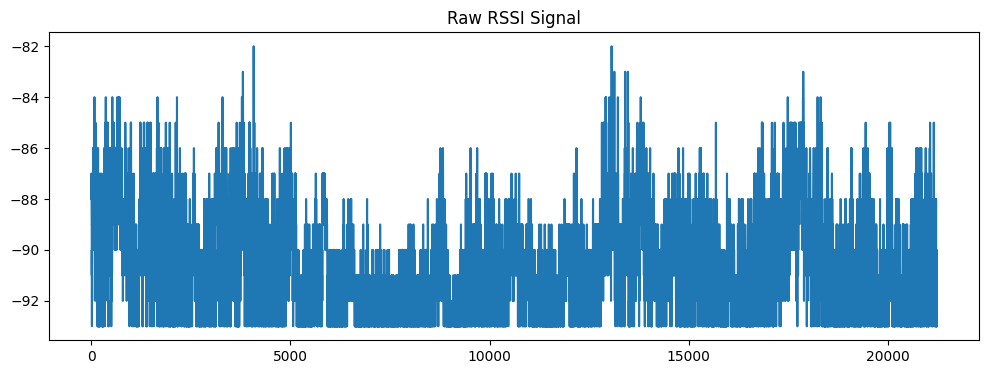

In [14]:
sample_run = df[df["run_id"]==df["run_id"].iloc[0]]

raw_signal = sample_run["rssi"].values

plt.figure(figsize=(12,4))
plt.plot(raw_signal)

plt.title("Raw RSSI Signal")

plt.show()

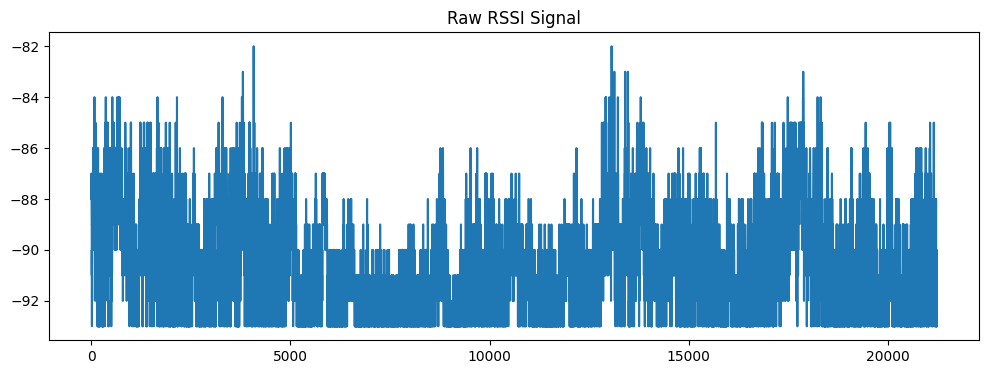

In [15]:
sample_run = df[df["run_id"]==df["run_id"].iloc[0]]

raw_signal = sample_run["rssi"].values

plt.figure(figsize=(12,4))
plt.plot(raw_signal)

plt.title("Raw RSSI Signal")

plt.show()

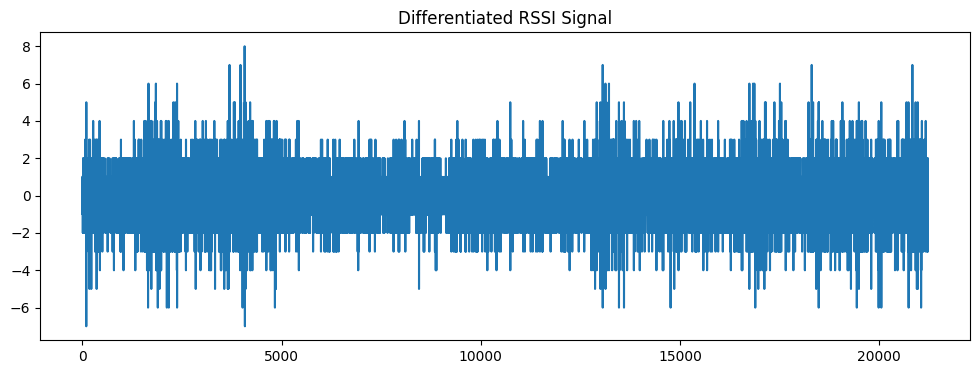

In [16]:
diff_signal = np.diff(raw_signal)

plt.figure(figsize=(12,4))
plt.plot(diff_signal)

plt.title("Differentiated RSSI Signal")

plt.show()

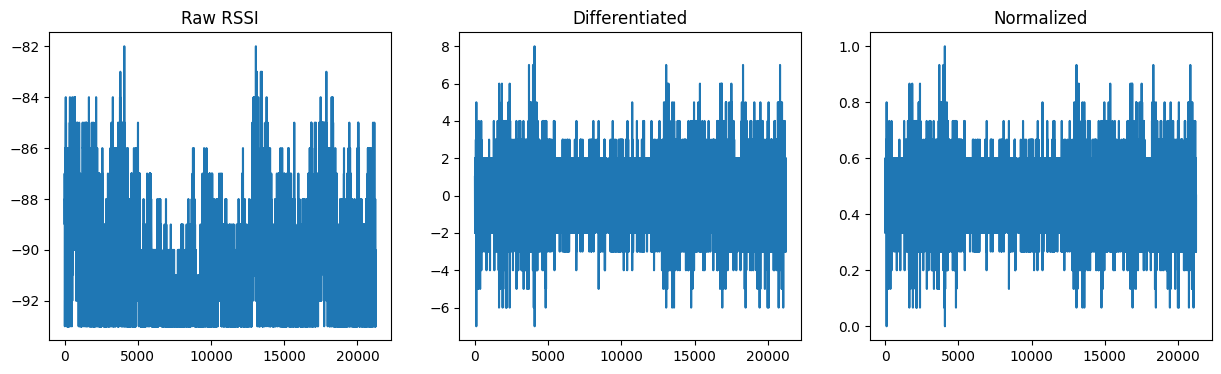

In [18]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.plot(raw_signal)
plt.title("Raw RSSI")

plt.subplot(1,3,2)
plt.plot(diff_signal)
plt.title("Differentiated")

plt.subplot(1,3,3)
plt.plot(norm_signal)
plt.title("Normalized")

plt.show()

In [19]:
frame_length = 500
step = int(frame_length * 0.5)

windows = []

for i in range(0, len(norm_signal)-frame_length, step):
    windows.append(norm_signal[i:i+frame_length])

windows = np.array(windows)

print("Number of windows:", windows.shape)

Number of windows: (83, 500)


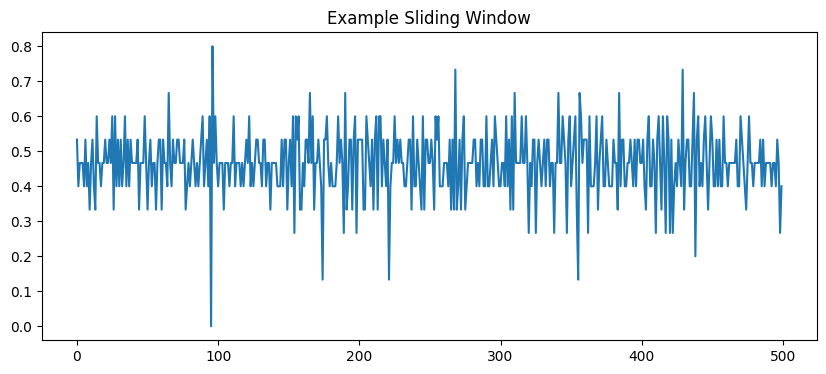

In [20]:
plt.figure(figsize=(10,4))

plt.plot(windows[0])

plt.title("Example Sliding Window")

plt.show()

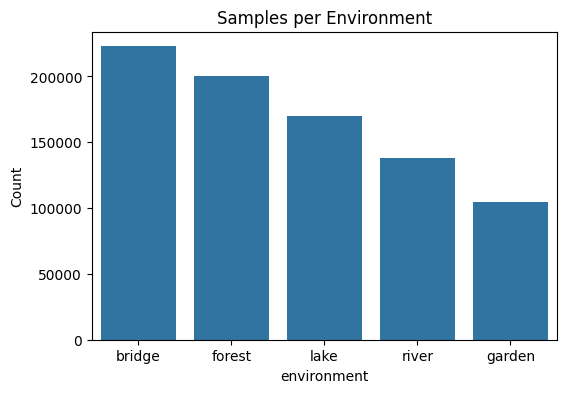

In [22]:
env_counts = df["environment"].value_counts()

plt.figure(figsize=(6,4))

sns.barplot(x=env_counts.index, y=env_counts.values)

plt.title("Samples per Environment")

plt.ylabel("Count")

plt.show()

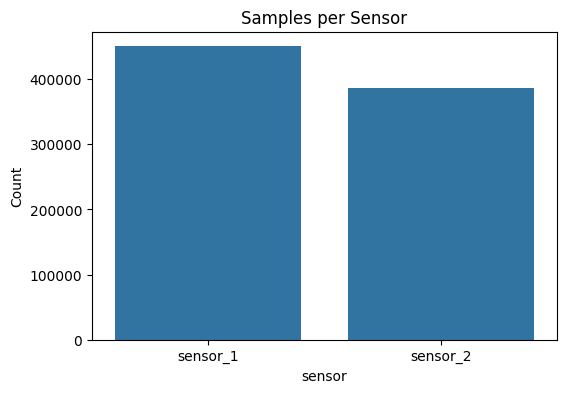

In [23]:
sensor_counts = df["sensor"].value_counts()

plt.figure(figsize=(6,4))

sns.barplot(x=sensor_counts.index, y=sensor_counts.values)

plt.title("Samples per Sensor")

plt.ylabel("Count")

plt.show()

In [1]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="Frame",
    y="Accuracy",
    hue="Model",
    data=results
)

plt.title("Effect of Frame Size")

plt.show()

NameError: name 'plt' is not defined